# Multi-Scale Taxi Demand Forecasting Evaluation

This notebook compares the final OD-level and zone-level forecasting results for one-hour-ahead Manhattan taxi demand. Model performance is evaluated across both spatial scales using consistent evaluation metrics.

## Importing Libraries and Setting Paths


In [54]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import geopandas as gpd
import matplotlib.dates as mdates

# Defining the project folders
project_dir = Path("..")

reports_dir = project_dir / "Output" / "Reports"
figures_dir = project_dir / "Output" / "Figures"

## Loading the Final Model Results

Loading the saved OD-level and zone-level model comparison tables for multi-scale evaluation.

In [55]:
# Loading the final comparison tables
od_results = pd.read_csv(reports_dir / "od_model_comparison_1h_jan2024.csv")

zone_results = pd.read_csv(reports_dir / "zone_model_comparison_1h_2024_01.csv")

# Displaying the results
print("OD-Level Results")
display(od_results.round(4))

print("\nZone-Level Results")
display(zone_results.round(4))

OD-Level Results


,Model,Split,MAE,RMSE,R2,WMAPE_%,MAPE_nonzero_%
0,Persistence Baseline,Validation,1.0762,2.0429,0.6144,69.4870,76.1540
1,Random Forest,Validation,0.9080,1.5962,0.7646,58.6320,55.1883
2,LSTM,Validation,0.8383,1.4992,0.7923,54.1321,53.5137
3,GAT-GRU,Validation,0.9065,1.8832,0.6723,58.5331,54.0694
4,Persistence Baseline,Test,0.9628,1.8992,0.6206,71.9174,76.8905
5,Random Forest,Test,0.8296,1.4763,0.7707,61.9695,55.2143
6,LSTM,Test,0.7614,1.4113,0.7905,56.8732,54.1297
7,GAT-GRU,Test,0.8227,1.7506,0.6777,61.4510,54.7488



Zone-Level Results


,Model,MAE,RMSE,R2,WMAPE,MAPE_nonzero
0,Random Forest,9.1915,17.4869,0.9520,16.8524,41.0734
1,LSTM,9.3782,16.7557,0.9559,17.1947,48.9136
2,GAT-GRU,13.7366,23.9438,0.9099,25.1858,102.6639
3,Persistence,14.0645,26.8789,0.8865,25.7869,58.9405


## Selecting the final test results

In [56]:
# Keeping only OD-level test results
od_test = od_results[od_results["Split"] == "Test"].copy()

# Standardising OD metric names
od_test = od_test.rename(columns={
    "WMAPE_%": "WMAPE",
    "MAPE_nonzero_%": "MAPE_nonzero"
})

# Removing the split column
od_test = od_test[["Model", "MAE", "RMSE", "R2", "WMAPE", "MAPE_nonzero"]].reset_index(drop=True)

# Preparing zone-level test results
zone_test = zone_results[["Model", "MAE", "RMSE", "R2", "WMAPE", "MAPE_nonzero"]].copy()

print("OD-Level Test Results")
display(od_test.round(4))

print("\nZone-Level Test Results")
display(zone_test.round(4))

OD-Level Test Results


,Model,MAE,RMSE,R2,WMAPE,MAPE_nonzero
0,Persistence Baseline,0.9628,1.8992,0.6206,71.9174,76.8905
1,Random Forest,0.8296,1.4763,0.7707,61.9695,55.2143
2,LSTM,0.7614,1.4113,0.7905,56.8732,54.1297
3,GAT-GRU,0.8227,1.7506,0.6777,61.4510,54.7488



Zone-Level Test Results


,Model,MAE,RMSE,R2,WMAPE,MAPE_nonzero
0,Random Forest,9.1915,17.4869,0.9520,16.8524,41.0734
1,LSTM,9.3782,16.7557,0.9559,17.1947,48.9136
2,GAT-GRU,13.7366,23.9438,0.9099,25.1858,102.6639
3,Persistence,14.0645,26.8789,0.8865,25.7869,58.9405


## Combining the Multi-Scale Test Results

Combining the final OD-level and zone-level test results into a single table for consistent comparison.

In [57]:
# Standardising the persistence model name
od_test["Model"] = od_test["Model"].replace(
    "Persistence Baseline", "Persistence"
)

# Adding the forecasting scale
od_test["Scale"] = "OD-Level"
zone_test["Scale"] = "Zone-Level"

# Combining both result tables
multi_scale_results = pd.concat([od_test, zone_test],ignore_index=True)

# Reordering the columns
multi_scale_results = multi_scale_results[
    ["Scale", "Model", "MAE", "RMSE", "R2", "WMAPE", "MAPE_nonzero"]]

display(multi_scale_results.round(4))

,Scale,Model,MAE,RMSE,R2,WMAPE,MAPE_nonzero
0,OD-Level,Persistence,0.9628,1.8992,0.6206,71.9174,76.8905
1,OD-Level,Random Forest,0.8296,1.4763,0.7707,61.9695,55.2143
2,OD-Level,LSTM,0.7614,1.4113,0.7905,56.8732,54.1297
3,OD-Level,GAT-GRU,0.8227,1.7506,0.6777,61.4510,54.7488
4,Zone-Level,Random Forest,9.1915,17.4869,0.9520,16.8524,41.0734
5,Zone-Level,LSTM,9.3782,16.7557,0.9559,17.1947,48.9136
6,Zone-Level,GAT-GRU,13.7366,23.9438,0.9099,25.1858,102.6639
7,Zone-Level,Persistence,14.0645,26.8789,0.8865,25.7869,58.9405


## Comparing WMAPE Across Spatial Scales

Comparing relative forecasting error across OD-level and zone-level prediction.

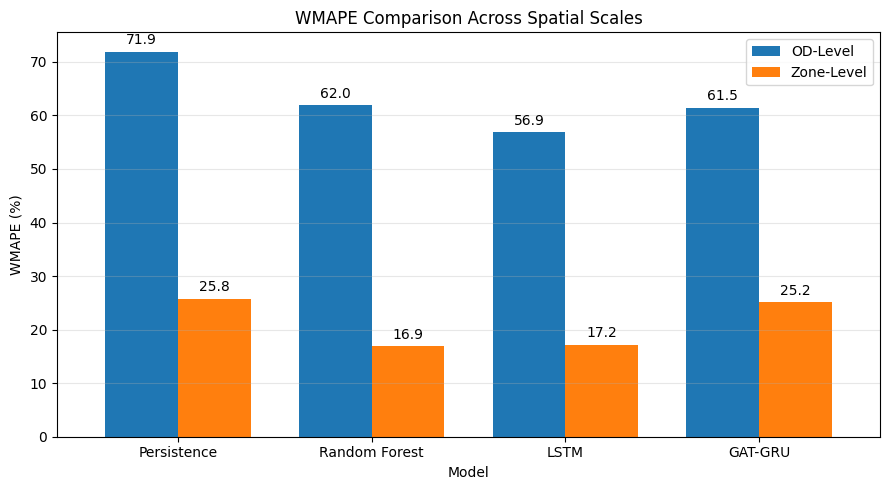

Figure saved: True


In [58]:
# Preparing WMAPE values
wmape_plot = multi_scale_results.pivot(
    index="Model",
    columns="Scale",
    values="WMAPE"
)

model_order = ["Persistence", "Random Forest", "LSTM", "GAT-GRU"]
wmape_plot = wmape_plot.reindex(model_order)

# Creating the figure
ax = wmape_plot.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.75
)

ax.set_title("WMAPE Comparison Across Spatial Scales")
ax.set_xlabel("Model")
ax.set_ylabel("WMAPE (%)")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)
ax.legend(title=None)

# Adding value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", padding=3)

plt.tight_layout()

# Saving the figure
wmape_figure_path = figures_dir / "multi_scale_wmape_comparison.png"
plt.savefig(wmape_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved:", wmape_figure_path.exists())

Zone-level forecasting achieved much lower WMAPE than OD-level forecasting across all models.

## Comparing R² Across Spatial Scales

Comparing the proportion of demand variation explained by each model at OD level and zone level.

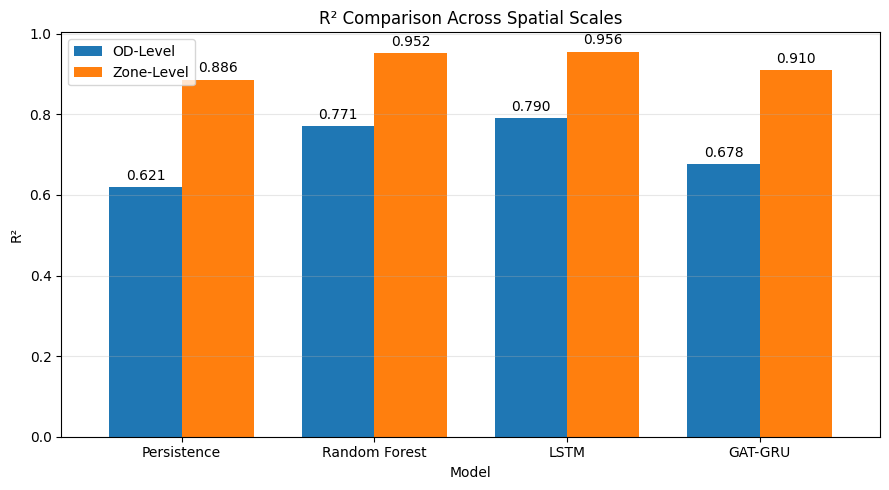

Figure saved: True


In [59]:
# Preparing R² values
r2_plot = multi_scale_results.pivot(
    index="Model",
    columns="Scale",
    values="R2"
)

r2_plot = r2_plot.reindex(model_order)

# Creating the figure
ax = r2_plot.plot(
    kind="bar",
    figsize=(9, 5),
    width=0.75
)

ax.set_title("R² Comparison Across Spatial Scales")
ax.set_xlabel("Model")
ax.set_ylabel("R²")
ax.tick_params(axis="x", rotation=0)
ax.grid(axis="y", alpha=0.3)
ax.legend(title=None)

# Adding value labels
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()

# Saving the figure
r2_figure_path = figures_dir / "multi_scale_r2_comparison.png"
plt.savefig(r2_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved:", r2_figure_path.exists())

Zone-level models achieved consistently higher R² values than OD-level models, showing that aggregated zone demand is more predictable than individual OD flows.

## Measuring WMAPE Reduction Across Spatial Scales
Calculating how much WMAPE decreases when moving from OD-level to zone-level forecasting.

In [60]:
# Calculating the WMAPE reduction for each model
scale_improvement = wmape_plot.copy()

scale_improvement["WMAPE_Reduction_%"] = (
    (scale_improvement["OD-Level"] - scale_improvement["Zone-Level"])
    / scale_improvement["OD-Level"]
) * 100

# Displaying the comparison
display(scale_improvement[["OD-Level", "Zone-Level", "WMAPE_Reduction_%"]].round(2))

Scale,OD-Level,Zone-Level,WMAPE_Reduction_%
Model,,,
Persistence,71.92,25.79,64.14
Random Forest,61.97,16.85,72.81
LSTM,56.87,17.19,69.77
GAT-GRU,61.45,25.19,59.01


## Identifying the Best Model at Each Spatial Scale

Identifying the model with the lowest WMAPE for each forecasting scale.

In [61]:
# Finding the model with the lowest WMAPE at each scale
best_models = (
    multi_scale_results
    .loc[multi_scale_results.groupby("Scale")["WMAPE"].idxmin()]
    [["Scale", "Model", "WMAPE", "R2"]]
    .reset_index(drop=True)
)

display(best_models.round(4))

,Scale,Model,WMAPE,R2
0,OD-Level,LSTM,56.8732,0.7905
1,Zone-Level,Random Forest,16.8524,0.9520


LSTM performed best at OD level, while Random Forest achieved the strongest zone-level performance based on WMAPE.

## Comparing Improvement Over Persistence

Measuring the WMAPE improvement achieved by each model compared with persistence.

In [62]:
# Getting persistence WMAPE for each scale
persistence = multi_scale_results[multi_scale_results["Model"] == "Persistence"].set_index("Scale")["WMAPE"]

# Calculating improvement over persistence
model_improvement = multi_scale_results[multi_scale_results["Model"] != "Persistence"].copy()

model_improvement["WMAPE_Improvement_%"] = model_improvement.apply(lambda x: (persistence[x["Scale"]] - x["WMAPE"])/ persistence[x["Scale"]] * 100,axis=1)

display(model_improvement[["Scale", "Model", "WMAPE", "WMAPE_Improvement_%"]].round(2))

,Scale,Model,WMAPE,WMAPE_Improvement_%
1,OD-Level,Random Forest,61.97,13.83
2,OD-Level,LSTM,56.87,20.92
3,OD-Level,GAT-GRU,61.45,14.55
4,Zone-Level,Random Forest,16.85,34.65
5,Zone-Level,LSTM,17.19,33.32
6,Zone-Level,GAT-GRU,25.19,2.33


## Comparing Test-Set Target Sparsity

Comparing the proportion of zero-demand observations in the final OD-level and zone-level test sets.

In [63]:
# Loading the final test prediction files
od_test_predictions = pd.read_csv(reports_dir / "lstm_test_predictions_1h_jan2024.csv")

zone_test_predictions = pd.read_csv(reports_dir / "zone_lstm_test_predictions.csv")

# Calculating zero-demand percentages
od_zero_pct = (od_test_predictions["target_1h"] == 0).mean() * 100
zone_zero_pct = (zone_test_predictions["actual_demand"] == 0).mean() * 100

# Creating the sparsity comparison
sparsity_comparison = pd.DataFrame({
    "Scale": ["OD-Level", "Zone-Level"],
    "Zero_Target_%": [od_zero_pct, zone_zero_pct]
})

display(sparsity_comparison.round(2))

,Scale,Zero_Target_%
0,OD-Level,58.05
1,Zone-Level,13.64


OD-level demand contains substantially more zero observations than zone-level demand, showing that OD forecasting is more sparse and fragmented.

## Visualising Target Sparsity

Comparing zero-demand observations across the two forecasting scales.

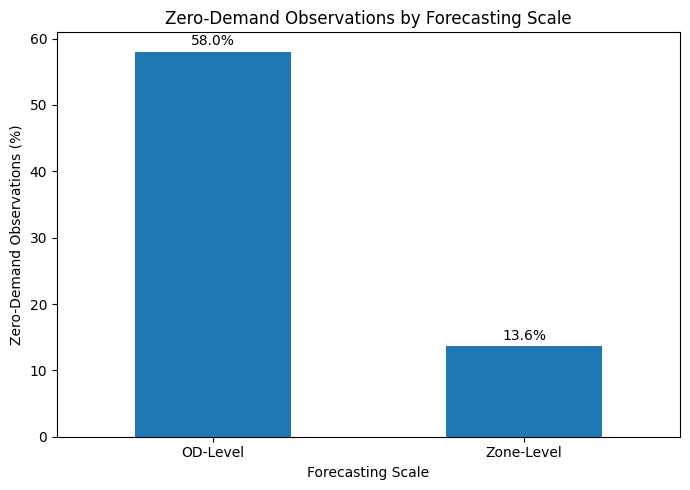

Figure saved: True


In [64]:
# Creating the sparsity comparison figure
ax = sparsity_comparison.plot(
    x="Scale",
    y="Zero_Target_%",
    kind="bar",
    figsize=(7, 5),
    legend=False
)

ax.set_title("Zero-Demand Observations by Forecasting Scale")
ax.set_xlabel("Forecasting Scale")
ax.set_ylabel("Zero-Demand Observations (%)")
ax.tick_params(axis="x", rotation=0)

# Adding percentage labels
for i, value in enumerate(sparsity_comparison["Zero_Target_%"]):
    ax.text(i, value + 1, f"{value:.1f}%", ha="center")

plt.tight_layout()

# Saving the figure
sparsity_figure_path = figures_dir / "multi_scale_target_sparsity.png"
plt.savefig(sparsity_figure_path, dpi=300, bbox_inches="tight")

plt.show()

print("Figure saved:", sparsity_figure_path.exists())

## Visualising the Forecasting Scales

Comparing the spatial representation used for OD-level and zone-level demand forecasting.

In [65]:
# Loading spatial data and final prediction outputs

processed_dir = project_dir / "Data" / "Processed"

# Finding and loading the taxi-zone shapefile
shapefile_path = next(project_dir.rglob("taxi_zones*.shp"))

zones = gpd.read_file(shapefile_path)

od_flows = pd.read_parquet(processed_dir / "hourly_od_flows_2024_01.parquet")

od_predictions = pd.read_csv(reports_dir / "lstm_test_predictions_1h_jan2024.csv")

zone_predictions = pd.read_csv(reports_dir / "zone_random_forest_test_predictions.csv")

od_predictions["prediction_hour"] = pd.to_datetime(od_predictions["prediction_hour"])

zone_predictions["target_hour"] = pd.to_datetime(zone_predictions["target_hour"])

excluded_zone_ids = [103, 104, 105, 194, 202]

manhattan_zones = zones[
    (zones["borough"] == "Manhattan") &
    (~zones["LocationID"].isin(excluded_zone_ids))
].copy()

manhattan_ids = manhattan_zones["LocationID"].tolist()

print("Manhattan zones:", len(manhattan_zones))
print("OD flow rows:", len(od_flows))
print("OD prediction rows:", len(od_predictions))
print("Zone prediction rows:", len(zone_predictions))

Manhattan zones: 64
OD flow rows: 1079578
OD prediction rows: 232128
Zone prediction rows: 6144


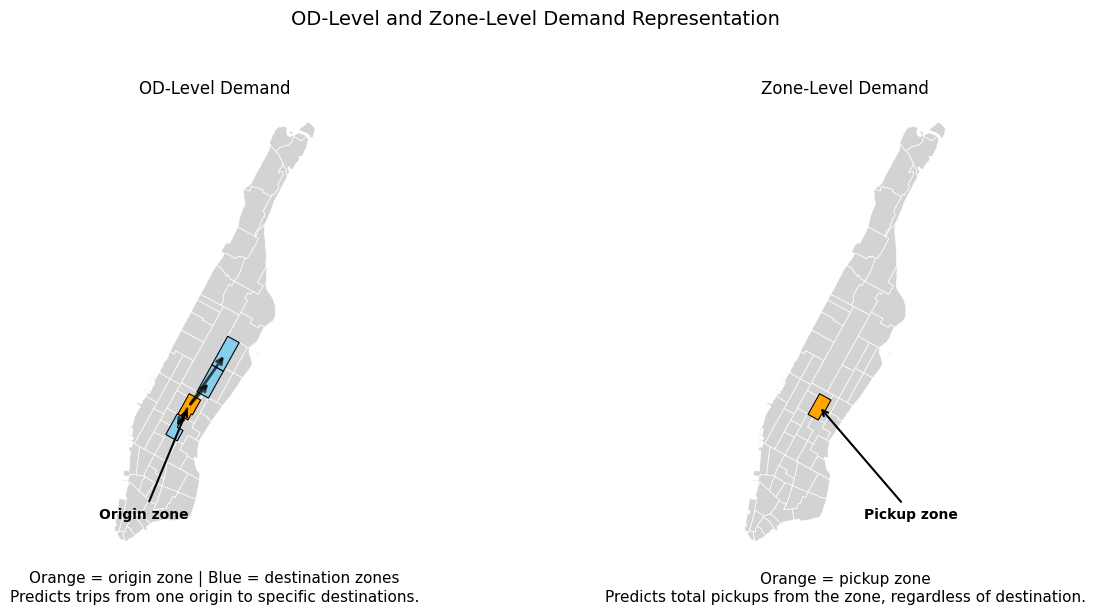

In [66]:
# Creating the two-scale comparison

fig, axes = plt.subplots(1, 2, figsize=(13, 7))

# OD-level figure

manhattan_zones.plot(
    ax=axes[0],
    color="lightgrey",
    edgecolor="white",
    linewidth=0.5
)

# Highlighting the origin zone
manhattan_zones[
    manhattan_zones["LocationID"] == origin_id
].plot(
    ax=axes[0],
    color="orange",
    edgecolor="black",
    linewidth=0.8
)

# Highlighting destination zones
destination_ids = top_destinations["DOLocationID"].tolist()

manhattan_zones[
    manhattan_zones["LocationID"].isin(destination_ids)
].plot(
    ax=axes[0],
    color="skyblue",
    edgecolor="black",
    linewidth=0.8
)

# Drawing OD arrows
for _, row in top_destinations.iterrows():

    destination = zone_centres[
        zone_centres["LocationID"] == row["DOLocationID"]
    ].iloc[0]

    axes[0].annotate(
        "",
        xy=(destination["x"], destination["y"]),
        xytext=(origin["x"], origin["y"]),
        arrowprops=dict(
            arrowstyle="->",
            linewidth=2,
            color="black",
            alpha=0.7
        )
    )

# Adding the explanation 
axes[0].annotate(
    "Origin zone",
    xy=(origin["x"], origin["y"]),
    xycoords="data",
    xytext=(0.18, 0.10),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", lw=1.5, color="black"),
    fontsize=10,
    fontweight="bold",
    ha="center"
)

axes[0].text(
    0.50, -0.08,
    "Orange = origin zone | Blue = destination zones\n"
    "Predicts trips from one origin to specific destinations.",
    transform=axes[0].transAxes,
    ha="center",
    fontsize=11
)

axes[0].set_title("OD-Level Demand", fontsize=12)
axes[0].set_axis_off()



# Zone-levelfigure

manhattan_zones.plot(
    ax=axes[1],
    color="lightgrey",
    edgecolor="white",
    linewidth=0.5
)

# Highlighting the pickup zone
manhattan_zones[
    manhattan_zones["LocationID"] == origin_id
].plot(
    ax=axes[1],
    color="orange",
    edgecolor="black",
    linewidth=0.8
)

# Adding explanation 
axes[1].annotate(
    "Pickup zone",
    xy=(origin["x"], origin["y"]),
    xycoords="data",
    xytext=(0.80, 0.10),
    textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", lw=1.5, color="black"),
    fontsize=10,
    fontweight="bold",
    ha="center"
)

axes[1].text(
    0.50, -0.08,
    "Orange = pickup zone\n"
    "Predicts total pickups from the zone, regardless of destination.",
    transform=axes[1].transAxes,
    ha="center",
    fontsize=11
)

axes[1].set_title("Zone-Level Demand", fontsize=12)
axes[1].set_axis_off()


# Final layout
fig.suptitle(
    "OD-Level and Zone-Level Demand Representation",
    fontsize=14
)

plt.tight_layout(rect=[0, 0.10, 1, 0.95])

plt.savefig(
    figures_dir / "od_vs_zone_forecasting_units.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Visualising Manhattan OD Flows

Visualising the highest-volume observed OD movements between the main Manhattan taxi zones during January 2024.

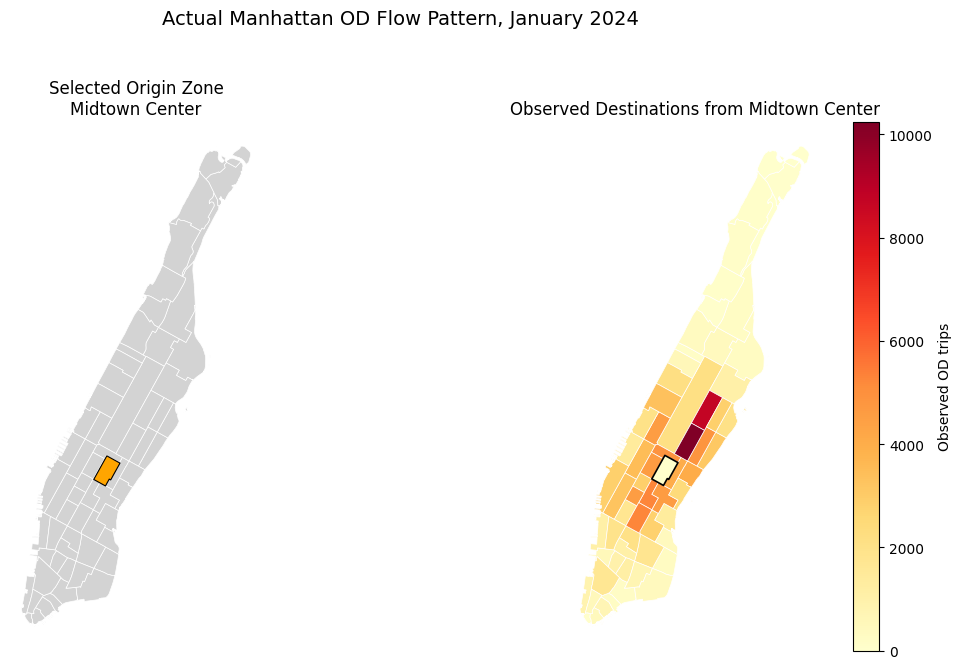

,Destination_Zone,Observed_Trips
0,Upper East Side South,10239.0
1,Upper East Side North,8723.0
2,Midtown South,5257.0
3,Union Sq,5252.0
4,Midtown North,4910.0
5,Lenox Hill West,4868.0
6,Times Sq/Theatre District,4639.0
7,Murray Hill,4610.0
8,Penn Station/Madison Sq West,4596.0
9,Lincoln Square East,4580.0


In [67]:
# Creating a Manhattan-only OD dataset
manhattan_od = od_flows[
    od_flows["PULocationID"].isin(manhattan_ids) &
    od_flows["DOLocationID"].isin(manhattan_ids) &
    (od_flows["PULocationID"] != od_flows["DOLocationID"])
].copy()

# Selecting the origin zone with the highest total outgoing OD demand
origin_summary = (
    manhattan_od
    .groupby("PULocationID")["trip_count"]
    .sum()
    .sort_values(ascending=False)
)

origin_id = origin_summary.index[0]

origin_name = (
    manhattan_zones
    .set_index("LocationID")
    .loc[origin_id, "zone"]
)

# Aggregating actual destination demand from the selected origin
destination_demand = (
    manhattan_od[manhattan_od["PULocationID"] == origin_id]
    .groupby("DOLocationID")["trip_count"]
    .sum()
    .reset_index()
)

# Merging the destination counts with the Manhattan zone boundaries
destination_map = manhattan_zones[
    ["LocationID", "zone", "geometry"]
].merge(
    destination_demand,
    left_on="LocationID",
    right_on="DOLocationID",
    how="left"
)

destination_map["trip_count"] = destination_map["trip_count"].fillna(0)

# Creating the two-panel figure
fig, axes = plt.subplots(1, 2, figsize=(12, 7))

# Left panel: selected origin zone
manhattan_zones.plot(
    ax=axes[0],
    color="lightgrey",
    edgecolor="white",
    linewidth=0.5
)

manhattan_zones[
    manhattan_zones["LocationID"] == origin_id
].plot(
    ax=axes[0],
    color="orange",
    edgecolor="black",
    linewidth=0.8
)

axes[0].set_title(
    f"Selected Origin Zone\n{origin_name}",
    fontsize=12
)
axes[0].set_axis_off()

# Right panel: actual destination demand from the selected origin
destination_map.plot(
    ax=axes[1],
    column="trip_count",
    cmap="YlOrRd",
    linewidth=0.5,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Observed OD trips"}
)

# Highlighting the same origin zone on the destination map
manhattan_zones[
    manhattan_zones["LocationID"] == origin_id
].plot(
    ax=axes[1],
    color="none",
    edgecolor="black",
    linewidth=1.2
)

axes[1].set_title(
    f"Observed Destinations from {origin_name}",
    fontsize=12
)
axes[1].set_axis_off()

# Final layout
fig.suptitle(
    "Actual Manhattan OD Flow Pattern, January 2024",
    fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

plt.savefig(
    figures_dir / "manhattan_od_flow_map.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

# Showing the top destination zones for the selected origin
top_destinations_table = (
    destination_map[destination_map["trip_count"] > 0]
    [["zone", "trip_count"]]
    .sort_values("trip_count", ascending=False)
    .head(10)
    .rename(columns={
        "zone": "Destination_Zone",
        "trip_count": "Observed_Trips"
    })
    .reset_index(drop=True)
)

display(top_destinations_table)

## Comparing OD-Level Predictions Over Time

Comparing observed and predicted OD demand during the final test period using the final LSTM model.

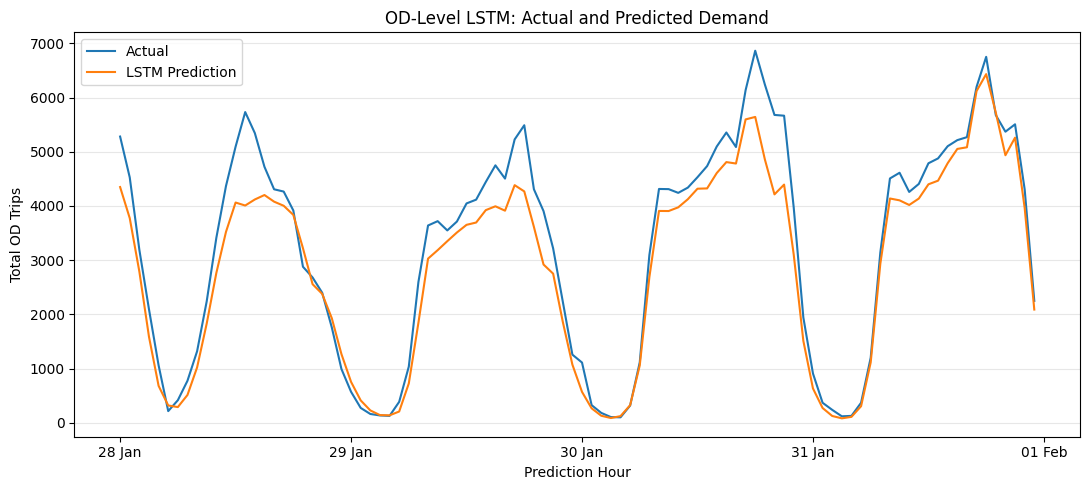

In [68]:
# Aggregating OD predictions by forecast hour

od_time = (
    od_predictions
    .groupby("prediction_hour", as_index=False)
    .agg(
        Actual_Demand=("target_1h", "sum"),
        Predicted_Demand=("lstm_pred_1h", "sum")
    )
)

# Creating the temporal comparison
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(
    od_time["prediction_hour"],
    od_time["Actual_Demand"],
    label="Actual"
)

ax.plot(
    od_time["prediction_hour"],
    od_time["Predicted_Demand"],
    label="LSTM Prediction"
)

ax.set_title("OD-Level LSTM: Actual and Predicted Demand")
ax.set_xlabel("Prediction Hour")
ax.set_ylabel("Total OD Trips")

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%d %b")
)
ax.grid(axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()

plt.savefig(
    figures_dir / "od_lstm_actual_vs_predicted_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The aggregated LSTM predictions follow the main temporal pattern of OD demand, although some peak periods are underestimated.

## Mapping OD-Level Prediction Performance

Mapping actual, predicted and residual OD demand by origin zone during the test period.

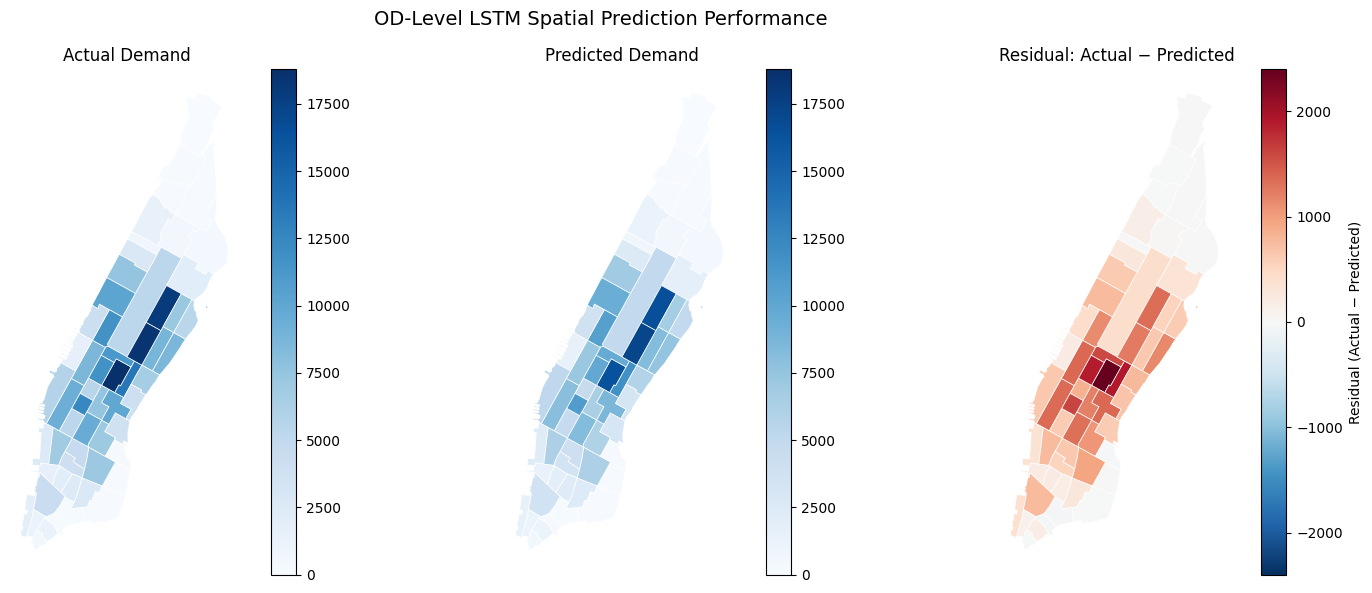

In [69]:
# Aggregating OD predictions by origin zone

od_spatial = (
    od_predictions
    .groupby("PULocationID", as_index=False)
    .agg(
        Actual_Demand=("target_1h", "sum"),
        Predicted_Demand=("lstm_pred_1h", "sum")
    )
)

# Calculating residuals
od_spatial["Residual"] = (
    od_spatial["Actual_Demand"] -
    od_spatial["Predicted_Demand"]
)

# Joining predictions to Manhattan zones
od_map = manhattan_zones.merge(
    od_spatial,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)

# Setting shared colour scales
demand_max = max(
    od_map["Actual_Demand"].max(),
    od_map["Predicted_Demand"].max()
)

residual_max = od_map["Residual"].abs().max()

# Creating the spatial comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

od_map.plot(
    column="Actual_Demand",
    ax=axes[0],
    cmap="Blues",
    vmin=0,
    vmax=demand_max,
    legend=True,
    edgecolor="white",
    linewidth=0.5
)

axes[0].set_title("Actual Demand")
axes[0].set_axis_off()

od_map.plot(
    column="Predicted_Demand",
    ax=axes[1],
    cmap="Blues",
    vmin=0,
    vmax=demand_max,
    legend=True,
    edgecolor="white",
    linewidth=0.5
)

axes[1].set_title("Predicted Demand")
axes[1].set_axis_off()

od_map.plot(
    column="Residual",
    ax=axes[2],
    cmap="RdBu_r",
    vmin=-residual_max,
    vmax=residual_max,
    legend=True,
    legend_kwds={
        "label": "Residual (Actual − Predicted)"
    },
    edgecolor="white",
    linewidth=0.5
)

axes[2].set_title("Residual: Actual − Predicted")
axes[2].set_axis_off()

fig.suptitle(
    "OD-Level LSTM Spatial Prediction Performance",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    figures_dir / "od_lstm_spatial_prediction_maps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The actual and predicted maps show a similar overall spatial pattern, indicating that the LSTM captures the main high-demand origin zones. Differences between them are shown more clearly in the residual map.

## Mapping Zone-Level Prediction Performance

Mapping actual, predicted and residual pickup demand across Manhattan during the test period.

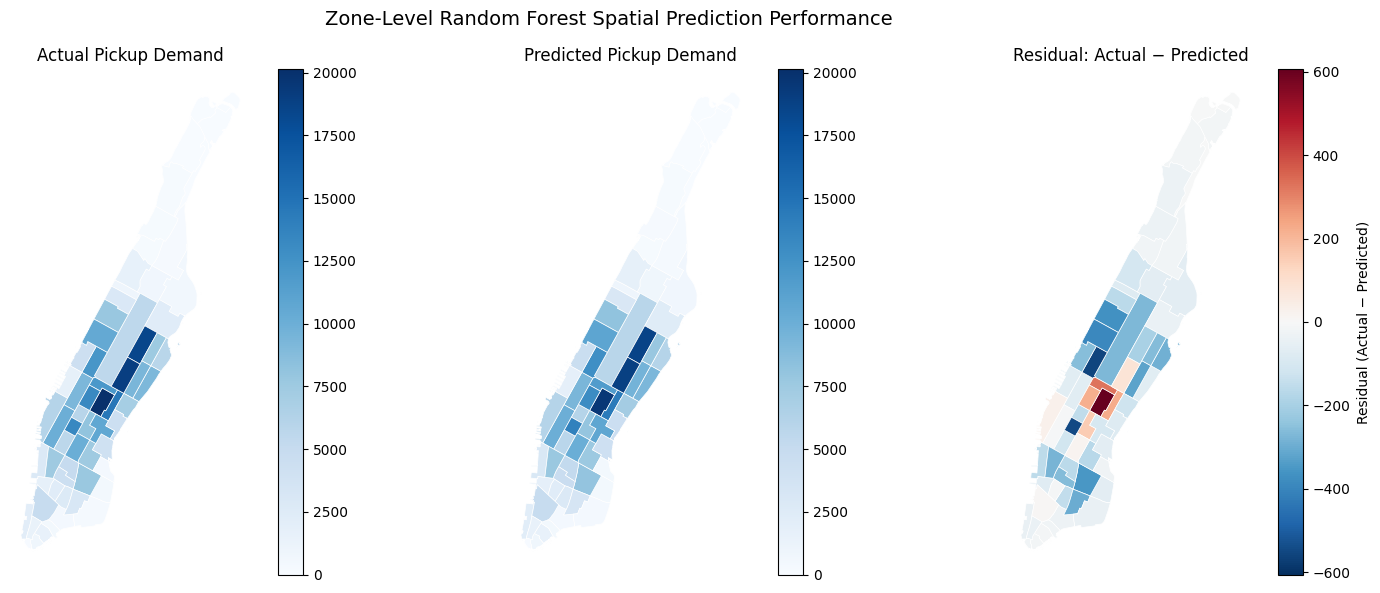

In [70]:
# Aggregating zone-level predictions by taxi zone

zone_spatial = (
    zone_predictions
    .groupby("LocationID", as_index=False)
    .agg(
        Actual_Demand=("target_1h", "sum"),
        Predicted_Demand=("rf_prediction", "sum")
    )
)

# Calculating residuals
zone_spatial["Residual"] = (
    zone_spatial["Actual_Demand"] -
    zone_spatial["Predicted_Demand"]
)

# Joining predictions to Manhattan taxi zones
zone_map = manhattan_zones.merge(
    zone_spatial,
    on="LocationID",
    how="left"
)

# Setting common colour scales
demand_max = max(
    zone_map["Actual_Demand"].max(),
    zone_map["Predicted_Demand"].max()
)

residual_max = zone_map["Residual"].abs().max()

# Creating the spatial comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

zone_map.plot(
    column="Actual_Demand",
    ax=axes[0],
    cmap="Blues",
    vmin=0,
    vmax=demand_max,
    legend=True,
    edgecolor="white",
    linewidth=0.5
)

axes[0].set_title("Actual Pickup Demand")
axes[0].set_axis_off()

zone_map.plot(
    column="Predicted_Demand",
    ax=axes[1],
    cmap="Blues",
    vmin=0,
    vmax=demand_max,
    legend=True,
    edgecolor="white",
    linewidth=0.5
)

axes[1].set_title("Predicted Pickup Demand")
axes[1].set_axis_off()

zone_map.plot(
    column="Residual",
    ax=axes[2],
    cmap="RdBu_r",
    vmin=-residual_max,
    vmax=residual_max,
    legend=True,
    legend_kwds={
        "label": "Residual (Actual − Predicted)"
    },
    edgecolor="white",
    linewidth=0.5
)

axes[2].set_title("Residual: Actual − Predicted")
axes[2].set_axis_off()

fig.suptitle(
    "Zone-Level Random Forest Spatial Prediction Performance",
    fontsize=14
)

plt.tight_layout()

plt.savefig(
    figures_dir / "zone_rf_spatial_prediction_maps.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The Random Forest reproduces the main spatial pattern of pickup demand across Manhattan. Residuals are relatively small compared with total zone demand, although some zones show local under- and overprediction.

## Saving the Final Results

In [71]:
# Saving final results
multi_scale_results.to_csv(reports_dir / "multi_scale_model_comparison_1h_2024_01.csv", index=False)
best_models.to_csv(reports_dir / "multi_scale_best_models_1h_2024_01.csv", index=False)
sparsity_comparison.to_csv(reports_dir / "multi_scale_sparsity_comparison_1h_2024_01.csv", index=False)
model_improvement.to_csv(reports_dir / "multi_scale_persistence_improvement_1h_2024_01.csv", index=False)

## Summarising the Multi-Scale Evaluation

Zone-level forecasting achieved substantially stronger performance than OD-level forecasting, supported by much lower target sparsity. LSTM performed best at OD level, while Random Forest performed best overall at zone level. GAT-GRU did not provide a consistent advantage over the simpler models.